# Chapter 13: introducing automatic optimization: let’s build a deep learning framework

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- What is a deep learning framework?
- Introduction to tensors
- Introduction to autograd
- How does addition backpropagation work?
- How to learn a framework
- Nonlinearity layers
- The embedding layer
- The cross-entropy layer
- The recurrent layer

## What is a deep learning framework?

Deep learning framework adalah tool yang mengurangi error, mempercepat development, dan meningkatkan runtime performance.

Sebelumnya, neural networks dibuat dari awal menggunakan NumPy agar cara kerja di balik framework dapat dipahami. Namun, untuk network yang lebih kompleks seperti LSTMs, kode NumPy menjadi sulit dibaca, dipakai, dan di-debug karena gradients bergerak ke banyak arah.

Framework dibuat untuk mengurangi kompleksitas tersebut. Framework dapat membantu training di GPU, mempercepat training, mengurangi jumlah kode, dan meminimalkan bug. Fitur utama framework adalah **automatic backpropagation** dan **automatic optimization**. Dengan fitur tersebut, pengguna cukup menulis forward propagation, lalu framework menangani backpropagation dan update weights.

Chapter ini tidak langsung memakai PyTorch atau TensorFlow. Chapter ini membangun framework kecil agar fungsi di balik framework modern dapat dipahami. Framework kecil ini mengikuti ide umum framework modern: tensor, autograd, layers, loss functions, dan optimizer.

## Introduction to tensors

Tensor adalah bentuk abstrak dari vector dan matrix.

Vector adalah one-dimensional tensor. Matrix adalah two-dimensional tensor. Higher-dimensional tensors adalah nested lists of numbers dengan dimensi lebih tinggi. Framework dimulai dengan membuat class `Tensor`.

In [1]:
import numpy as np

class Tensor(object):
  def __init__(self, data):
    self.data = np.array(data)

  def __add__(self, other):
    return Tensor(self.data + other.data)

  def __repr__(self):
    return str(self.data.__repr__())

  def __str__(self):
    return str(self.data.__str__())

x = Tensor([1, 2, 3, 4, 5])
print(x)

y = x + x
print(y)

[1 2 3 4 5]
[ 2  4  6  8 10]


Versi pertama `Tensor` hanya menyimpan data dalam NumPy array dan mendukung operasi addition. Operasi lain dapat ditambahkan dengan membuat method baru pada class tersebut.

## Introduction to automatic gradient computation (autograd)

Sebelumnya, backpropagation dilakukan manual. Sekarang, logic tersebut dibuat otomatis.

Autograd bekerja dengan menyimpan computation graph. Setiap tensor hasil operasi menyimpan tensor pembuatnya (`creators`) dan jenis operasi yang membuatnya (`creation_op`). Dengan informasi ini, gradient dapat dibackpropagate secara recursive.

In [2]:
import numpy as np

class Tensor(object):
  def __init__(self, data, creators=None, creation_op=None):
    self.data = np.array(data)
    self.creation_op = creation_op
    self.creators = creators
    self.grad = None

  def backward(self, grad):
    self.grad = grad

    if self.creation_op == "add":
      self.creators[0].backward(grad)
      self.creators[1].backward(grad)

  def __add__(self, other):
    return Tensor(
      self.data + other.data,
      creators=[self, other],
      creation_op="add"
    )

  def __repr__(self):
    return str(self.data.__repr__())

  def __str__(self):
    return str(self.data.__str__())

x = Tensor([1, 2, 3, 4, 5])
y = Tensor([2, 2, 2, 2, 2])

z = x + y
z.backward(Tensor(np.array([1, 1, 1, 1, 1])))

print(x.grad)
print(y.grad)
print(z.creators)
print(z.creation_op)

[1 1 1 1 1]
[1 1 1 1 1]
[array([1, 2, 3, 4, 5]), array([2, 2, 2, 2, 2])]
add


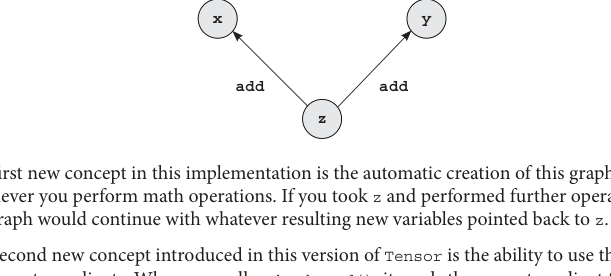

Ketika `z = x + y`, `z` menyimpan bahwa ia dibuat dari `x` dan `y` melalui operasi `add`. Saat `z.backward()` dipanggil, gradient diteruskan ke `x` dan `y`.

Autograd ini juga recursive. Jika hasil addition dipakai untuk operation berikutnya, graph akan terus tersambung, lalu backward dapat berjalan mundur melalui graph.

In [3]:
a = Tensor([1, 2, 3, 4, 5])
b = Tensor([2, 2, 2, 2, 2])
c = Tensor([5, 4, 3, 2, 1])
d = Tensor([-1, -2, -3, -4, -5])

e = a + b
f = c + d
g = e + f

g.backward(Tensor(np.array([1, 1, 1, 1, 1])))

print(a.grad)

[1 1 1 1 1]


## A quick checkpoint

Dynamic computation graph adalah graph yang dibangun saat forward propagation berjalan. Framework seperti DyNet dan PyTorch menggunakan pendekatan ini. Static computation graph didefinisikan sebelum forward propagation dimulai.

Dynamic graph biasanya lebih mudah untuk eksperimen. Static graph biasanya lebih cepat karena bisa dioptimasi sebelum runtime. Chapter ini memakai dynamic computation graph.

## Tensors that are used multiple times

Autograd dasar memiliki bug ketika tensor yang sama dipakai lebih dari sekali.

Jika tensor `b` dipakai dalam dua cabang graph, gradient untuk `b` seharusnya merupakan jumlah gradient dari kedua cabang. Versi sederhana sebelumnya hanya menimpa gradient lama dengan gradient baru.

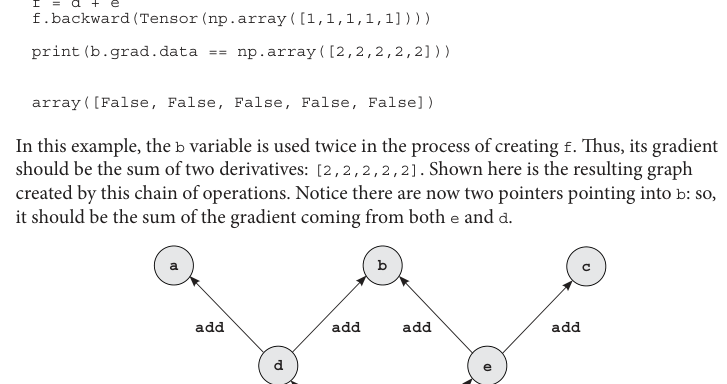

Untuk menyelesaikan ini, Tensor perlu:

- Menyimpan jumlah children yang memakai tensor tersebut.
- Mengakumulasi gradients dari beberapa children.
- Menunggu sampai semua gradients dari children sudah diterima sebelum meneruskan backward ke creators.

## Upgrading autograd to support multiuse tensors

Kode berikut adalah versi Tensor yang lebih lengkap. Versi ini memperbaiki multiuse tensors dan menambahkan operasi yang dibutuhkan sepanjang chapter: addition, negation, subtraction, multiplication, sum, expand, transpose, matrix multiplication, sigmoid, tanh, indexing, dan cross entropy.

In [4]:
import numpy as np

class Tensor(object):
  def __init__(
    self,
    data,
    autograd=False,
    creators=None,
    creation_op=None,
    id=None
  ):
    self.data = np.array(data)
    self.creators = creators
    self.creation_op = creation_op
    self.grad = None
    self.autograd = autograd
    self.children = {}

    if id is None:
      id = np.random.randint(0, 100000)

    self.id = id

    if creators is not None:
      for c in creators:
        if self.id not in c.children:
          c.children[self.id] = 1
        else:
          c.children[self.id] += 1

  def all_children_grads_accounted_for(self):
    for id, cnt in self.children.items():
      if cnt != 0:
        return False

    return True

  def backward(self, grad=None, grad_origin=None):
    if not self.autograd:
      return

    if grad is None:
      grad = Tensor(np.ones_like(self.data))

    if grad_origin is not None:
      if self.children[grad_origin.id] == 0:
        raise Exception("cannot backprop more than once")
      else:
        self.children[grad_origin.id] -= 1

    if self.grad is None:
      self.grad = grad
    else:
      self.grad += grad

    if self.creators is not None and (
      self.all_children_grads_accounted_for() or grad_origin is None
    ):
      if self.creation_op == "add":
        self.creators[0].backward(self.grad, self)
        self.creators[1].backward(self.grad, self)

      if self.creation_op == "neg":
        self.creators[0].backward(self.grad.__neg__(), self)

      if self.creation_op == "sub":
        self.creators[0].backward(Tensor(self.grad.data), self)
        self.creators[1].backward(Tensor(self.grad.__neg__().data), self)

      if self.creation_op == "mul":
        self.creators[0].backward(self.grad * self.creators[1], self)
        self.creators[1].backward(self.grad * self.creators[0], self)

      if self.creation_op == "mm":
        act = self.creators[0]
        weights = self.creators[1]

        act.backward(self.grad.mm(weights.transpose()), self)
        weights.backward(self.grad.transpose().mm(act).transpose(), self)

      if self.creation_op == "transpose":
        self.creators[0].backward(self.grad.transpose(), self)

      if self.creation_op is not None and "sum" in self.creation_op:
        dim = int(self.creation_op.split("_")[1])
        ds = self.creators[0].data.shape[dim]
        self.creators[0].backward(self.grad.expand(dim, ds), self)

      if self.creation_op is not None and "expand" in self.creation_op:
        dim = int(self.creation_op.split("_")[1])
        self.creators[0].backward(self.grad.sum(dim), self)

      if self.creation_op == "sigmoid":
        ones = Tensor(np.ones_like(self.grad.data))
        self.creators[0].backward(self.grad * (self * (ones - self)), self)

      if self.creation_op == "tanh":
        ones = Tensor(np.ones_like(self.grad.data))
        self.creators[0].backward(self.grad * (ones - (self * self)), self)

      if self.creation_op == "index_select":
        new_grad = np.zeros_like(self.creators[0].data)
        indices_ = self.index_select_indices.data.flatten()
        grad_ = self.grad.data.reshape(len(indices_), -1)

        for i in range(len(indices_)):
          new_grad[indices_[i]] += grad_[i]

        self.creators[0].backward(Tensor(new_grad), self)

      if self.creation_op == "cross_entropy":
        dx = self.softmax_output - self.target_dist
        self.creators[0].backward(Tensor(dx), self)

  def __add__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data + other.data,
        autograd=True,
        creators=[self, other],
        creation_op="add"
      )

    return Tensor(self.data + other.data)

  def __neg__(self):
    if self.autograd:
      return Tensor(
        self.data * -1,
        autograd=True,
        creators=[self],
        creation_op="neg"
      )

    return Tensor(self.data * -1)

  def __sub__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data - other.data,
        autograd=True,
        creators=[self, other],
        creation_op="sub"
      )

    return Tensor(self.data - other.data)

  def __mul__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data * other.data,
        autograd=True,
        creators=[self, other],
        creation_op="mul"
      )

    return Tensor(self.data * other.data)

  def sum(self, dim):
    if self.autograd:
      return Tensor(
        self.data.sum(dim),
        autograd=True,
        creators=[self],
        creation_op="sum_" + str(dim)
      )

    return Tensor(self.data.sum(dim))

  def expand(self, dim, copies):
    trans_cmd = list(range(0, len(self.data.shape)))
    trans_cmd.insert(dim, len(self.data.shape))

    new_shape = list(self.data.shape) + [copies]
    new_data = self.data.repeat(copies).reshape(new_shape)
    new_data = new_data.transpose(trans_cmd)

    if self.autograd:
      return Tensor(
        new_data,
        autograd=True,
        creators=[self],
        creation_op="expand_" + str(dim)
      )

    return Tensor(new_data)

  def transpose(self):
    if self.autograd:
      return Tensor(
        self.data.transpose(),
        autograd=True,
        creators=[self],
        creation_op="transpose"
      )

    return Tensor(self.data.transpose())

  def mm(self, x):
    if self.autograd:
      return Tensor(
        self.data.dot(x.data),
        autograd=True,
        creators=[self, x],
        creation_op="mm"
      )

    return Tensor(self.data.dot(x.data))

  def sigmoid(self):
    if self.autograd:
      return Tensor(
        1 / (1 + np.exp(-self.data)),
        autograd=True,
        creators=[self],
        creation_op="sigmoid"
      )

    return Tensor(1 / (1 + np.exp(-self.data)))

  def tanh(self):
    if self.autograd:
      return Tensor(
        np.tanh(self.data),
        autograd=True,
        creators=[self],
        creation_op="tanh"
      )

    return Tensor(np.tanh(self.data))

  def index_select(self, indices):
    if self.autograd:
      new = Tensor(
        self.data[indices.data],
        autograd=True,
        creators=[self],
        creation_op="index_select"
      )
      new.index_select_indices = indices
      return new

    return Tensor(self.data[indices.data])

  def cross_entropy(self, target_indices):
    temp = np.exp(self.data - np.max(self.data, axis=len(self.data.shape) - 1, keepdims=True))
    softmax_output = temp / np.sum(temp, axis=len(self.data.shape) - 1, keepdims=True)

    t = target_indices.data.flatten()
    p = softmax_output.reshape(len(t), -1)
    target_dist = np.eye(p.shape[1])[t]

    loss = -(np.log(p + 1e-12) * target_dist).sum(1).mean()

    if self.autograd:
      out = Tensor(
        loss,
        autograd=True,
        creators=[self],
        creation_op="cross_entropy"
      )
      out.softmax_output = softmax_output
      out.target_dist = target_dist
      return out

    return Tensor(loss)

  def __repr__(self):
    return str(self.data.__repr__())

  def __str__(self):
    return str(self.data.__str__())

Pada kode buku, bagian subtraction backpropagation memiliki argumen kosong pada `backward(, self)`. Notebook ini memperbaikinya menjadi gradient negatif untuk creator kedua.

In [5]:
a = Tensor([1, 2, 3, 4, 5], autograd=True)
b = Tensor([2, 2, 2, 2, 2], autograd=True)
c = Tensor([5, 4, 3, 2, 1], autograd=True)

d = a + b
e = b + c
f = d + e

f.backward(Tensor(np.array([1, 1, 1, 1, 1])))

print(b.grad.data == np.array([2, 2, 2, 2, 2]))

[ True  True  True  True  True]


## How does addition backpropagation work?

Support untuk operasi baru ditambahkan di dua tempat:

- Forward function pada class Tensor.
- Backpropagation logic pada method `backward()`.

Untuk addition, forward function membuat tensor baru dengan `creation_op="add"` dan menyimpan creators. Saat backward, gradient dikirim ke dua creators karena addition memiliki dua input.

## Adding support for negation

Negation mirip dengan addition, tetapi hanya memiliki satu creator. Saat backward, gradient dikalikan -1.

In [6]:
a = Tensor([1, 2, 3, 4, 5], autograd=True)
b = Tensor([2, 2, 2, 2, 2], autograd=True)
c = Tensor([5, 4, 3, 2, 1], autograd=True)

d = a + (-b)
e = (-b) + c
f = d + e

f.backward(Tensor(np.array([1, 1, 1, 1, 1])))

print(b.grad.data == np.array([-2, -2, -2, -2, -2]))

[ True  True  True  True  True]


## Adding support for additional functions

Chapter ini menambahkan subtraction, multiplication, sum, expand, transpose, dan matrix multiplication. Fungsi-fungsi tersebut membuat framework dapat melakukan forward dan backward untuk network yang lebih umum.

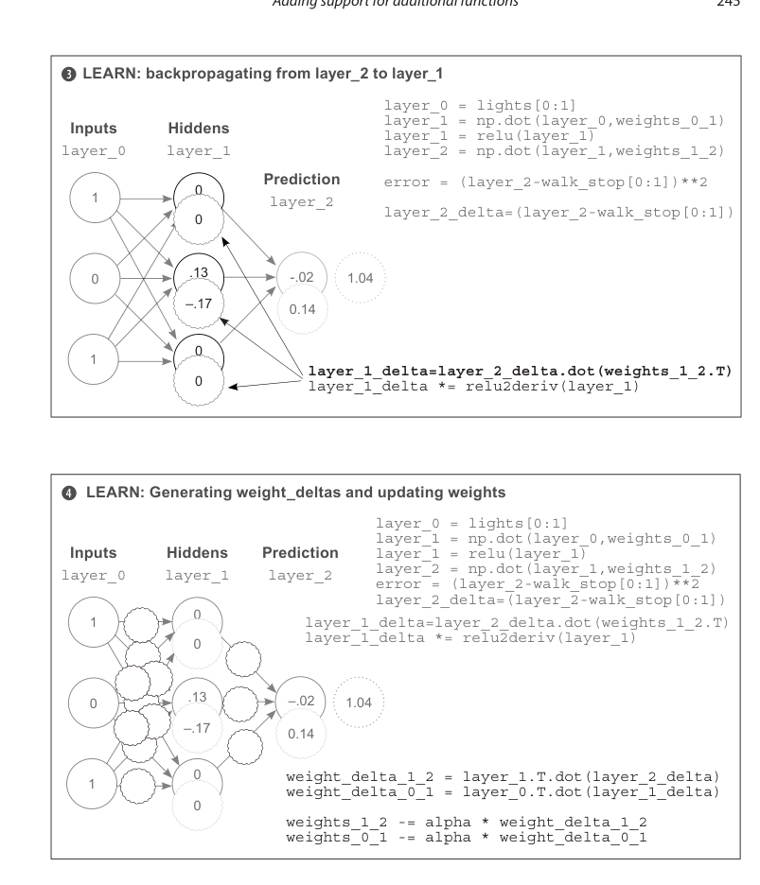

Backpropagation tetap melakukan hal yang sama seperti chapter sebelumnya: error signal bergerak mundur melalui operasi yang digunakan pada forward propagation. Perbedaannya adalah logic-nya sekarang tersusun dalam class `Tensor`, bukan ditulis manual setiap membuat model.

## Using autograd to train a neural network

Dengan autograd, tidak perlu menulis backpropagation logic manual.

Kode berikut adalah contoh training neural network kecil dengan Tensor dan autograd.

In [7]:
import numpy as np

np.random.seed(0)

data = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

w = []
w.append(Tensor(np.random.rand(2, 3), autograd=True))
w.append(Tensor(np.random.rand(3, 1), autograd=True))

for i in range(10):
  pred = data.mm(w[0]).mm(w[1])
  loss = ((pred - target) * (pred - target)).sum(0)

  loss.backward(Tensor(np.ones_like(loss.data)))

  for w_ in w:
    w_.data -= w_.grad.data * 0.1
    w_.grad.data *= 0

  print(loss)

[0.58128304]
[0.48988149]
[0.41375111]
[0.34489412]
[0.28210124]
[0.2254484]
[0.17538853]
[0.1324231]
[0.09682769]
[0.06849361]


Forward propagation hanya menulis prediction dan loss. Computation graph menyimpan temporary variables, sedangkan `backward()` menangani gradient.

## Adding automatic optimization

Stochastic gradient descent optimizer hanya mengurangi parameter dengan gradient dikali alpha.

In [8]:
class SGD(object):
  def __init__(self, parameters, alpha=0.1):
    self.parameters = parameters
    self.alpha = alpha

  def zero(self):
    for p in self.parameters:
      if p.grad is not None:
        p.grad.data *= 0

  def step(self, zero=True):
    for p in self.parameters:
      p.data -= p.grad.data * self.alpha

      if zero:
        p.grad.data *= 0

In [9]:
import numpy as np

np.random.seed(0)

data = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

w = []
w.append(Tensor(np.random.rand(2, 3), autograd=True))
w.append(Tensor(np.random.rand(3, 1), autograd=True))

optim = SGD(parameters=w, alpha=0.1)

for i in range(10):
  pred = data.mm(w[0]).mm(w[1])
  loss = ((pred - target) * (pred - target)).sum(0)

  loss.backward(Tensor(np.ones_like(loss.data)))
  optim.step()

  print(loss)

[0.58128304]
[0.48988149]
[0.41375111]
[0.34489412]
[0.28210124]
[0.2254484]
[0.17538853]
[0.1324231]
[0.09682769]
[0.06849361]


## Adding support for layer types

Layer abstraction membungkus forward propagation yang sering dipakai. Contoh paling dasar adalah linear layer.

In [10]:
class Layer(object):
  def __init__(self):
    self.parameters = []

  def get_parameters(self):
    return self.parameters

class Linear(Layer):
  def __init__(self, n_inputs, n_outputs):
    super().__init__()

    W = np.random.randn(n_inputs, n_outputs) * np.sqrt(2.0 / n_inputs)

    self.weight = Tensor(W, autograd=True)
    self.bias = Tensor(np.zeros(n_outputs), autograd=True)

    self.parameters.append(self.weight)
    self.parameters.append(self.bias)

  def forward(self, input):
    return input.mm(self.weight) + self.bias.expand(0, len(input.data))

`Linear` menyimpan weight dan bias, lalu `forward()` menjalankan matrix multiplication dan menambahkan bias.

## Layers that contain layers

`Sequential` menjalankan beberapa layers secara berurutan, output layer sebelumnya menjadi input layer berikutnya.

In [11]:
class Sequential(Layer):
  def __init__(self, layers=[]):
    super().__init__()
    self.layers = layers

  def add(self, layer):
    self.layers.append(layer)

  def forward(self, input):
    for layer in self.layers:
      input = layer.forward(input)

    return input

  def get_parameters(self):
    params = []

    for layer in self.layers:
      params += layer.get_parameters()

    return params

In [12]:
np.random.seed(0)

data = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

model = Sequential([Linear(2, 3), Linear(3, 1)])
optim = SGD(parameters=model.get_parameters(), alpha=0.05)

for i in range(10):
  pred = model.forward(data)
  loss = ((pred - target) * (pred - target)).sum(0)

  loss.backward(Tensor(np.ones_like(loss.data)))
  optim.step()

  print(loss)

[2.33428272]
[0.06743796]
[0.0521849]
[0.04079507]
[0.03184365]
[0.02479336]
[0.01925443]
[0.01491699]
[0.01153118]
[0.00889602]


## Loss-function layers

Loss function juga dapat dibuat sebagai layer tanpa weights.

In [13]:
class MSELoss(Layer):
  def __init__(self):
    super().__init__()

  def forward(self, pred, target):
    return ((pred - target) * (pred - target)).sum(0)

In [14]:
np.random.seed(0)

data = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

model = Sequential([Linear(2, 3), Linear(3, 1)])
criterion = MSELoss()
optim = SGD(parameters=model.get_parameters(), alpha=0.05)

for i in range(10):
  pred = model.forward(data)
  loss = criterion.forward(pred, target)

  loss.backward(Tensor(np.ones_like(loss.data)))
  optim.step()

  print(loss)

[2.33428272]
[0.06743796]
[0.0521849]
[0.04079507]
[0.03184365]
[0.02479336]
[0.01925443]
[0.01491699]
[0.01153118]
[0.00889602]


## How to learn a framework

Framework secara sederhana adalah autograd ditambah daftar prebuilt layers dan optimizers.

Workflow mempelajari framework baru adalah mencari contoh paling sederhana, mengubahnya sedikit demi sedikit, memahami API autograd-nya, lalu memodifikasi contoh tersebut sampai menjadi experiment yang diinginkan.

Chapter ini juga menambahkan convenience pada `Tensor.backward()` agar tidak perlu selalu mengirim gradient 1 saat backward pertama kali dipanggil. Pada implementasi notebook ini, convenience tersebut sudah dimasukkan: jika `grad is None`, gradient otomatis dibuat sebagai `np.ones_like(self.data)`.

## Nonlinearity layers

Untuk chapter berikutnya, framework membutuhkan `sigmoid()` dan `tanh()`. Keduanya sudah ditambahkan pada class Tensor. Sekarang dibuat layer `Tanh` dan `Sigmoid`.

In [15]:
class Tanh(Layer):
  def __init__(self):
    super().__init__()

  def forward(self, input):
    return input.tanh()

class Sigmoid(Layer):
  def __init__(self):
    super().__init__()

  def forward(self, input):
    return input.sigmoid()

In [16]:
np.random.seed(0)

data = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

model = Sequential([Linear(2, 3), Tanh(), Linear(3, 1), Sigmoid()])
criterion = MSELoss()
optim = SGD(parameters=model.get_parameters(), alpha=1)

for i in range(10):
  pred = model.forward(data)
  loss = criterion.forward(pred, target)

  loss.backward(Tensor(np.ones_like(loss.data)))
  optim.step()

  print(loss)

[1.06372865]
[0.75148144]
[0.57384259]
[0.39574294]
[0.2482279]
[0.15515294]
[0.10423398]
[0.07571169]
[0.05837623]
[0.04700013]


## The embedding layer

Embedding layer menerjemahkan indices menjadi activations.

Jika vocabulary berisi 200 words, embedding layer memiliki 200 rows. Setiap row adalah embedding untuk satu word. Input yang diberikan ke embedding layer adalah indices, bukan raw words.

In [17]:
identity = np.eye(5)

print(identity)
print(identity[np.array([[1, 2, 3, 4], [2, 3, 4, 0]])])

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
[[[0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]]

 [[0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]
  [1. 0. 0. 0. 0.]]]


NumPy dapat menerima matrix of indices untuk memilih rows dari matrix. Ini menjadi dasar forward propagation embedding layer.

## Adding indexing to autograd

Agar embedding layer bisa dilatih, autograd harus mendukung indexing. Method `index_select()` sudah ditambahkan di class Tensor sebelumnya.

Saat backpropagation, gradient ditempatkan kembali ke rows yang sama dengan rows yang dipilih saat forward propagation.

In [18]:
x = Tensor(np.eye(5), autograd=True)
x.index_select(Tensor([[1, 2, 3], [2, 3, 4]])).backward()

print(x.grad)

[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [1. 1. 1. 1. 1.]]


Index 2 dan 3 mendapat gradient dua kali karena muncul dua kali dalam indices.

## The embedding layer (revisited)

Sekarang embedding layer dapat dibuat dengan `index_select()`.

In [19]:
class Embedding(Layer):
  def __init__(self, vocab_size, dim):
    super().__init__()

    self.vocab_size = vocab_size
    self.dim = dim

    # Di buku ada typo parenthesis. Versi ini diperbaiki agar runnable.
    weight = (np.random.rand(vocab_size, dim) - 0.5) / dim
    self.weight = Tensor(weight, autograd=True)

    self.parameters.append(self.weight)

  def forward(self, input):
    return self.weight.index_select(input)

In [20]:
np.random.seed(0)

data = Tensor(np.array([1, 2, 1, 2]), autograd=True)
target = Tensor(np.array([[0], [1], [0], [1]]), autograd=True)

embed = Embedding(5, 3)
model = Sequential([embed, Tanh(), Linear(3, 1), Sigmoid()])

criterion = MSELoss()
optim = SGD(parameters=model.get_parameters(), alpha=0.5)

for i in range(10):
  pred = model.forward(data)
  loss = criterion.forward(pred, target)

  loss.backward(Tensor(np.ones_like(loss.data)))
  optim.step()

  print(loss)

[0.98874126]
[0.6658868]
[0.45639889]
[0.31608168]
[0.2260925]
[0.16877423]
[0.13120515]
[0.10555487]
[0.08731868]
[0.07387834]


Kode tersebut melatih embedding agar input indices 1 dan 2 berkorelasi dengan target 0 dan 1.

## The cross-entropy layer

Cross entropy menggabungkan softmax dan loss calculation. Convention ini umum pada frameworks karena lebih efisien daripada membuat softmax dan loss sebagai dua module terpisah.

Method `cross_entropy()` sudah ditambahkan pada class Tensor. Sekarang dibuat layer `CrossEntropyLoss`.

In [21]:
class CrossEntropyLoss(object):
  def __init__(self):
    super().__init__()

  def forward(self, input, target):
    return input.cross_entropy(target)

In [22]:
np.random.seed(0)

data = Tensor(np.array([1, 2, 1, 2]), autograd=True)
target = Tensor(np.array([0, 1, 0, 1]), autograd=True)

model = Sequential([Embedding(3, 3), Tanh(), Linear(3, 4)])

criterion = CrossEntropyLoss()
optim = SGD(parameters=model.get_parameters(), alpha=0.1)

for i in range(10):
  pred = model.forward(data)
  loss = criterion.forward(pred, target)

  loss.backward()
  optim.step()

  print(loss)

1.388503243488828
0.9558181509239981
0.6823083585775717
0.5095259967476387
0.395744914727467
0.3175252728521051
0.26172228619511984
0.22061283923829353
0.18946427334709087
0.1652738926374861


Dengan cross entropy, network tidak perlu menambahkan softmax di akhir forward propagation. Softmax dilakukan di dalam loss.

## The recurrent neural network layer

RNNCell dibuat dengan tiga linear layers:

- `w_ih`: input-to-hidden
- `w_hh`: hidden-to-hidden
- `w_ho`: hidden-to-output

Hidden state menjadi input dan output dari setiap forward step. Activation dapat berupa sigmoid atau tanh.

In [23]:
class RNNCell(Layer):
  def __init__(self, n_inputs, n_hidden, n_output, activation="sigmoid"):
    super().__init__()

    self.n_inputs = n_inputs
    self.n_hidden = n_hidden
    self.n_output = n_output

    if activation == "sigmoid":
      self.activation = Sigmoid()
    elif activation == "tanh":
      # Di buku tertulis self.activation == Tanh(), yang hanya comparison.
      # Versi ini diperbaiki menjadi assignment.
      self.activation = Tanh()
    else:
      raise Exception("Non-linearity not found")

    self.w_ih = Linear(n_inputs, n_hidden)
    self.w_hh = Linear(n_hidden, n_hidden)
    self.w_ho = Linear(n_hidden, n_output)

    self.parameters += self.w_ih.get_parameters()
    self.parameters += self.w_hh.get_parameters()
    self.parameters += self.w_ho.get_parameters()

  def forward(self, input, hidden):
    from_prev_hidden = self.w_hh.forward(hidden)
    combined = self.w_ih.forward(input) + from_prev_hidden
    new_hidden = self.activation.forward(combined)
    output = self.w_ho.forward(new_hidden)

    return output, new_hidden

  def init_hidden(self, batch_size=1):
    return Tensor(np.zeros((batch_size, self.n_hidden)), autograd=True)

## Training the recurrent layer

Bagian akhir chapter melatih RNNCell pada Babi dataset seperti chapter sebelumnya. Dataset diunduh dan diekstrak jika belum ada.

In [24]:
!wget -q http://www.thespermwhale.com/jaseweston/babi/tasks_1-20_v1-1.tar.gz
!tar -xzf tasks_1-20_v1-1.tar.gz

tar (child): tasks_1-20_v1-1.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [25]:
import sys
import random
import math
from collections import Counter
import numpy as np
from pathlib import Path

dataset_path = Path("tasksv11/en/qa1_single-supporting-fact_train.txt")

if not dataset_path.exists():
  raise FileNotFoundError(
    "Dataset Babi belum ditemukan. Jalankan cell download dan extract terlebih dahulu."
  )

with open(dataset_path, "r", encoding="utf-8") as f:
  raw = f.readlines()

tokens = []

for line in raw[0:1000]:
  tokens.append(line.lower().replace("\n", "").split(" ")[1:])

new_tokens = []

for line in tokens:
  new_tokens.append(["-"] * (6 - len(line)) + line)

tokens = new_tokens

vocab = set()

for sent in tokens:
  for word in sent:
    vocab.add(word)

vocab = list(vocab)

word2index = {}

for i, word in enumerate(vocab):
  word2index[word] = i

def words2indices(sentence):
  idx = []

  for word in sentence:
    idx.append(word2index[word])

  return idx

indices = []

for line in tokens:
  idx = []

  for w in line:
    idx.append(word2index[w])

  indices.append(idx)

data = np.array(indices)

print(tokens[0])
print("Data shape:", data.shape)
print("Vocab size:", len(vocab))

FileNotFoundError: Dataset Babi belum ditemukan. Jalankan cell download dan extract terlebih dahulu.

In [ ]:
np.random.seed(0)

embed = Embedding(vocab_size=len(vocab), dim=16)
model = RNNCell(n_inputs=16, n_hidden=16, n_output=len(vocab), activation="sigmoid")

criterion = CrossEntropyLoss()
params = model.get_parameters() + embed.get_parameters()

optim = SGD(parameters=params, alpha=0.05)

for iter in range(1000):
  batch_size = 100
  total_loss = 0

  hidden = model.init_hidden(batch_size=batch_size)

  for t in range(5):
    input = Tensor(data[0:batch_size, t], autograd=True)
    rnn_input = embed.forward(input=input)

    output, hidden = model.forward(input=rnn_input, hidden=hidden)

    target = Tensor(data[0:batch_size, t + 1], autograd=True)
    loss = criterion.forward(output, target)

    loss.backward()
    optim.step()

    total_loss += loss.data

  if iter % 200 == 0:
    p_correct = (target.data == np.argmax(output.data, axis=1)).mean()
    print_loss = total_loss / (len(data) / batch_size)

    print("Loss:", print_loss, "% Correct:", p_correct)

In [ ]:
batch_size = 1

hidden = model.init_hidden(batch_size=batch_size)

for t in range(5):
  input = Tensor(data[0:batch_size, t], autograd=True)
  rnn_input = embed.forward(input=input)
  output, hidden = model.forward(input=rnn_input, hidden=hidden)

target = Tensor(data[0:batch_size, t + 1], autograd=True)
loss = criterion.forward(output, target)

ctx = ""

for idx in data[0:batch_size][0][0:-1]:
  ctx += vocab[idx] + " "

print("Context:", ctx)
print("Pred:", vocab[output.data.argmax()])

RNNCell ini menyelesaikan task yang sama seperti chapter sebelumnya dengan kode yang lebih sederhana karena framework menangani autograd, optimizer, layers, embedding, dan loss.

## Summary

Framework adalah abstraction yang efisien untuk forward dan backward logic.

Chapter ini membangun framework kecil dari awal. Komponen utamanya adalah `Tensor`, autograd, optimizer, layer abstraction, nonlinear layers, embedding layer, cross-entropy loss, dan recurrent layer.

Framework membuat kode lebih readable, lebih cepat ditulis, dan lebih minim bug karena backpropagation serta update weights tidak perlu ditulis manual untuk setiap model. Framework yang paling mirip dengan struktur yang dibangun di chapter ini adalah PyTorch.